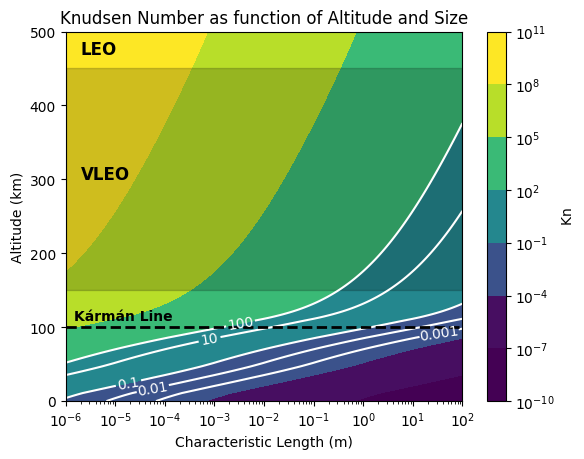

In [2]:
# Contour Plot of Knudsen number as function of altitude and size

from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import numpy as np
import ussa1976


altitude = np.arange(0.0, 500001, 1000.0)
length = np.logspace(-6, 2, 500)

ds = ussa1976.compute(z=altitude, variables=['mfp'])

lam = np.array(ds['mfp'])[:, None]   # shape (101,1)
LEN, ALT = np.meshgrid(length, altitude)
knudsen_number = lam / LEN

# Create Figure
plt.figure()
ax = plt.subplot(1, 1, 1)
ax.set_xlabel('Characteristic Length (m)')
ax.set_ylabel('Altitude (km)')
ax.set_title('Knudsen Number as function of Altitude and Size')

contour = ax.contourf(
    LEN,
    ALT/1e3,
    knudsen_number,
    norm=LogNorm(vmin=1e-6, vmax=1e8),
    cmap='viridis'
)
ax.set_xscale('log')

regimes = [0.001, 0.01, 0.1, 10, 100]

ax.clabel(
    ax.contour(
        LEN,
        ALT/1e3,
        knudsen_number,
        levels=regimes,
        colors='white'
    ),
    fmt='%g'
)

# Karman line
ax.axhline(100, color='k', linestyle='--', linewidth=2)
ax.text(
    length[10],      # right side of plot
    110,             # slightly above line
    'Kármán Line',
    color='k',
    ha='left',
    fontsize=10,
    weight='bold'
)

ax.axhspan(150, 450, color='k', alpha=0.18)
ax.text(2e-6, 300, 'VLEO', fontsize=12, weight='bold')
ax.text(2e-6, 470, 'LEO', fontsize=12, weight='bold')

cbar = plt.colorbar(contour)
cbar.set_label(r'$\mathrm{Kn}$')
plt.show()


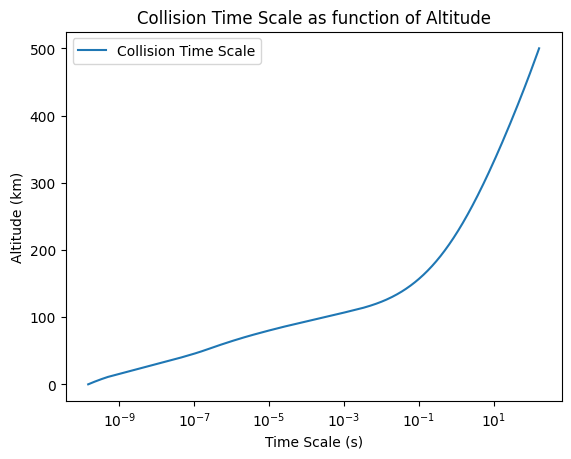

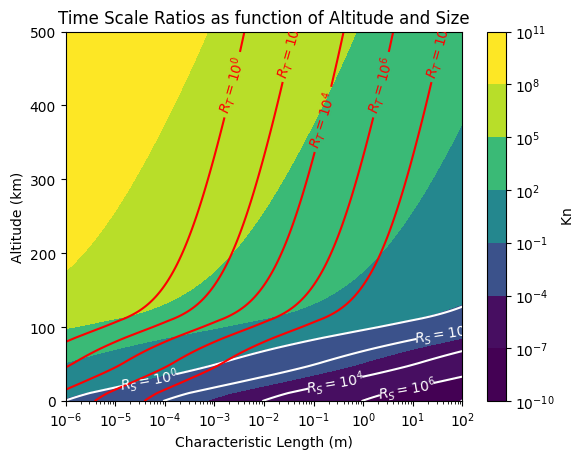

In [24]:
# density, bulk modulus, shear modulus

polymer = {}
polymer['density'] = 1200  # kg/m^3
polymer['bulk_modulus'] = 3e9  # Pa
polymer['shear_modulus'] = 1e9  # Pa
polymer['cp'] = 2e3  # J/kg/K
polymer['k'] = 0.25  # W/m/K

glass = {}
glass['density'] = 2500  # kg/m^3
glass['bulk_modulus'] = 4e10  # Pa
glass['shear_modulus'] = 3e10  # Pa
glass['cp'] = 840  # J/kg/K
glass['k'] = 1.0  # W/m/K

al_alloy = {}
al_alloy['density'] = 2700  # kg/m^3
al_alloy['bulk_modulus'] = 7.6e10  # Pa
al_alloy['shear_modulus'] = 2.6e10  # Pa
al_alloy['cp'] = 900  # J/kg/K
al_alloy['k'] = 200  # W/m/K

steel_ti_alloy = {}
steel_ti_alloy['density'] = 6000  # kg/m^3
steel_ti_alloy['bulk_modulus'] = 1.4e11  # Pa
steel_ti_alloy['shear_modulus'] = 6e10  # Pa
steel_ti_alloy['cp'] = 500  # J/kg/K
steel_ti_alloy['k'] = 30  # W/m/K

ceramics = {}
ceramics['density'] = 3600  # kg/m^3
ceramics['bulk_modulus'] = 2.25e11  # Pa
ceramics['shear_modulus'] = 1.75e11  # Pa
ceramics['cp'] = 800  # J/kg/K
ceramics['k'] = 100  # W/m/K

materials = [polymer, glass, al_alloy, steel_ti_alloy, ceramics]

for material in materials:
    material['speed_of_sound'] = np.sqrt(
        (material['bulk_modulus'] + 4/3 * material['shear_modulus']) / material['density']
    )
    material['alpha'] = material['k'] / (material['density'] * material['cp'])

cbar = 450.0  # m/s
tau_collision = lam / cbar

fig = plt.figure()
ax = plt.subplot(1, 1, 1)
ax.plot(tau_collision, altitude/1e3, label='Collision Time Scale')
ax.set_xscale('log')
ax.set_ylabel('Altitude (km)')
ax.set_xlabel('Time Scale (s)')
ax.set_title('Collision Time Scale as function of Altitude')
ax.legend()

for material in materials:
    material['Nsteps'] = (
        LEN / material['speed_of_sound']
    ) / tau_collision

names = [
    'Polymer',
    'Glass',
    'Al Alloy',
    'Steel/Ti',
    'Ceramic'
]

for material, name in zip(materials, names):
    material['name'] = name
    # print(f"{name}: c_L = {material['speed_of_sound']:.1f} m/s, alpha = {material['alpha']:.2e} m^2/s")

avg_eng_material = {}
avg_eng_material['speed_of_sound'] = np.mean([m['speed_of_sound'] for m in materials])
avg_eng_material['alpha'] = 1e-7

structural_time_scale = LEN / avg_eng_material['speed_of_sound']
thermal_time_scale = LEN**2 / avg_eng_material['alpha']
structrual_time_scale_ratio = structural_time_scale / tau_collision
thermal_time_scale_ratio = thermal_time_scale / tau_collision

fig = plt.figure()
ax = plt.subplot(1, 1, 1)
ax.set_xlabel('Characteristic Length (m)')
ax.set_ylabel('Altitude (km)')
ax.set_title('Time Scale Ratios as function of Altitude and Size')
ax.set_xscale('log')
contour = ax.contourf(
    LEN,
    ALT/1e3,
    knudsen_number,
    norm=LogNorm(vmin=1e-6, vmax=1e8),
    cmap='viridis'
)

# Structural time scale ratio contours
structural_contours = ax.contour(
    LEN,
    ALT/1e3,
    structrual_time_scale_ratio,
    levels=[1, 1e2, 1e4, 1e6, 1e8],
    colors='white',
    #linestyles='dashed'
)
fmt = {
    1:      r'$R_S=10^{0}$',
    1e2:    r'$R_S=10^{2}$',
    1e4:    r'$R_S=10^{4}$',
    1e6:    r'$R_S=10^{6}$',
    1e8:    r'$R_S=10^{8}$'
}
ax.clabel(structural_contours, fmt=fmt) 

# Thermal time scale ratio contours
thermal_contours = ax.contour(
    LEN,
    ALT/1e3,
    thermal_time_scale_ratio,
    levels=[1, 1e2, 1e4, 1e6, 1e8],
    colors='red',
    #linestyles='dotted'
)
fmt = {
    1:      r'$R_T=10^{0}$',
    1e2:    r'$R_T=10^{2}$',
    1e4:    r'$R_T=10^{4}$',
    1e6:    r'$R_T=10^{6}$',
    1e8:    r'$R_T=10^{8}$'
}
ax.clabel(thermal_contours, fmt=fmt)

cbar = plt.colorbar(contour)
cbar.set_label(r'$\mathrm{Kn}$')

